In [1]:
print("hi")

hi


In [2]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [ ]:
#defining the state for the graph
class art_state(TypedDict):
    a:int
    b:int
    add:int
    sub:int
    mul:int
    div:float


In [ ]:
# defining the graph
graph=StateGraph(art_state)

In [6]:
def add_sub(state:art_state):
    a=state['a']
    b=state['b']
    add=a+b
    sub=a-b

    return {'add':add,"sub":sub}

def mul_div(state:art_state):
    a=state['a']
    b=state['b']
    mul=a*b
    div=a/b
    return {"mul":mul,"div":div}


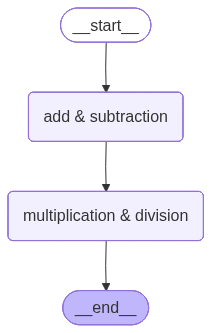

In [7]:
# defining the nodes,edges

graph.add_node('add & subtraction',add_sub)
graph.add_node('multiplication & division',mul_div)

graph.add_edge(START,'add & subtraction')
graph.add_edge('add & subtraction','multiplication & division')
graph.add_edge('multiplication & division',END)


# compailing the graph to create the workflow

workflow=graph.compile()
workflow


In [8]:
initial_state={'a':20,'b':3}

output=workflow.invoke(initial_state)
print(output)

{'a': 20, 'b': 3, 'add': 23, 'sub': 17, 'mul': 60, 'div': 6.666666666666667}


In [9]:
state=art_state(**output)


In [10]:
print(state)

{'a': 20, 'b': 3, 'add': 23, 'sub': 17, 'mul': 60, 'div': 6.666666666666667}


In [11]:
print(f' addition of {state["a"]},{state["b"]} is {state["add"]}')
print(f' sub of {state["a"]},{state["b"]} is {state["sub"]}')
print(f' mul of {state["a"]},{state["b"]} is {state["mul"]}')
print(f' div of {state["a"]},{state["b"]} is {state["div"]}')

 addition of 20,3 is 23
 sub of 20,3 is 17
 mul of 20,3 is 60
 div of 20,3 is 6.666666666666667
